In [33]:
import joblib

import umap
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
 
from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset, load_ovr_inference_memmap
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.configs import artifact_stem
from sklearn.metrics import confusion_matrix
from birdclef_2026_ml.training.eval import plot_confusion_matrix
from birdclef_2026_ml.models.hierarchical import combine_soft_proba

paths = load_project_paths()

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 5 seconds chunks

In [17]:
run_name = "run_chunks_overlap"
experiment_name = "sgd_baseline"

dataset = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=False)
experiment_dir = paths.experiment_dir(run_name, experiment_name)

le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")
le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")

val_idx = np.load(experiment_dir / "val_indices.npy")
inference_dir = experiment_dir / "inference"
inference_probas = load_ovr_inference_memmap(inference_dir, "sgdclassifier_ovr", dual=True)

In [35]:
val_true_class_name = le_class_name.inverse_transform(dataset.y[val_idx, 0])
val_true_primary_label = le_primary_label.inverse_transform(dataset.y[val_idx, 1])

val_proba_class_name = inference_probas.class_name[val_idx, :]
val_proba_primary_label = inference_probas.primary_label[val_idx, :]
val_soft_proba_primary_label = combine_soft_proba(val_proba_class_name, val_proba_primary_label)

val_pred_class_name = le_class_name.inverse_transform(np.argmax(val_proba_class_name, axis=1))
val_pred_primary_label = le_primary_label.inverse_transform(np.argmax(val_proba_primary_label, axis=1))
val_soft_pred_primary_label = le_primary_label.inverse_transform(np.argmax(val_soft_proba_primary_label, axis=1))

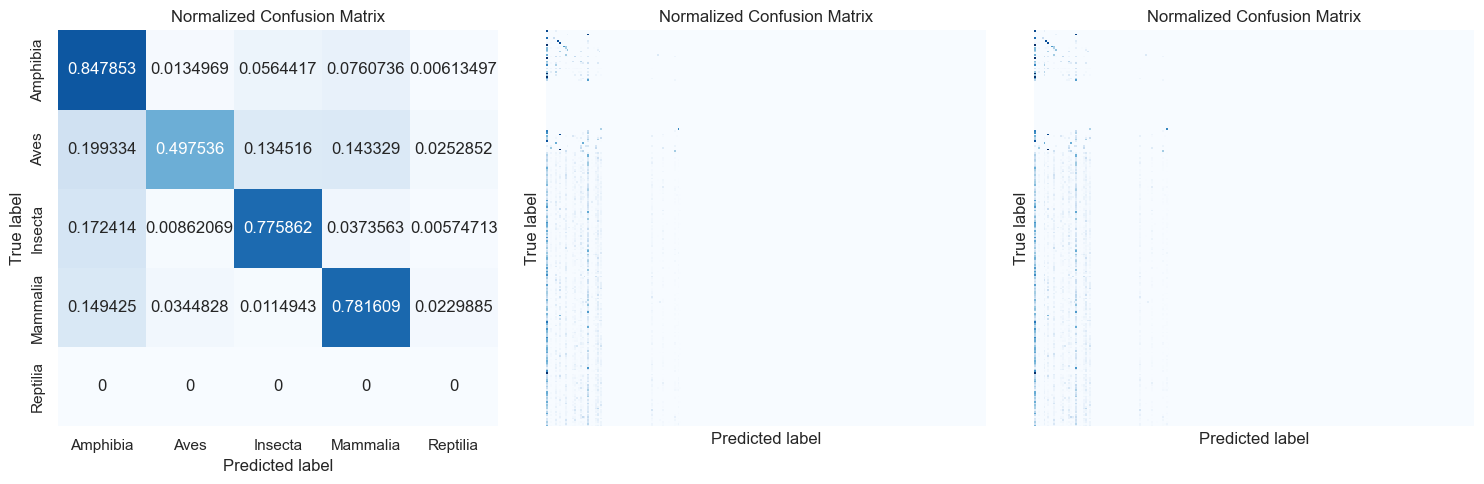

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_confusion_matrix(
    val_true_class_name,
    val_pred_class_name,
    labels=le_class_name.classes_,
    annot=True,
    ax=axes[0]
)

plot_confusion_matrix(
    val_true_primary_label,
    val_pred_primary_label,
    labels=le_primary_label.classes_,
    annot=False,
    ax=axes[1]
)

plot_confusion_matrix(
    val_true_primary_label,
    val_pred_primary_label,
    labels=le_primary_label.classes_,
    annot=False,
    ax=axes[2]
)

axes[0].set_title("Class_name")
axes[1].set_title("Primary label")

plt.tight_layout()

<Axes: title={'center': 'Normalized Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

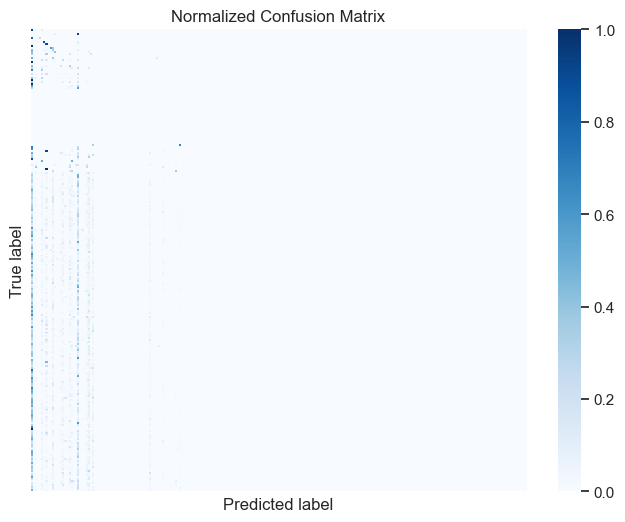

In [31]:
plot_confusion_matrix(
    val_true_primary_label,
    val_pred_primary_label,
    labels=le_primary_label.classes_,
    normalize="true",
    annot=False
)

<Axes: title={'center': 'Normalized Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

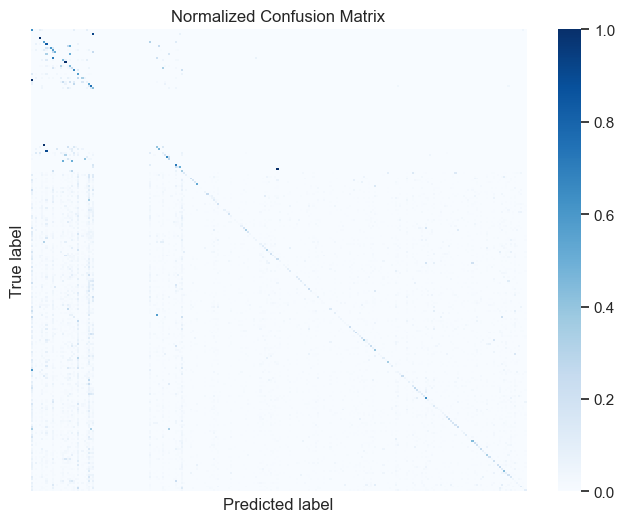

In [36]:
plot_confusion_matrix(
    val_true_primary_label,
    val_soft_pred_primary_label,
    labels=le_primary_label.classes_,
    normalize="true",
    annot=False
)

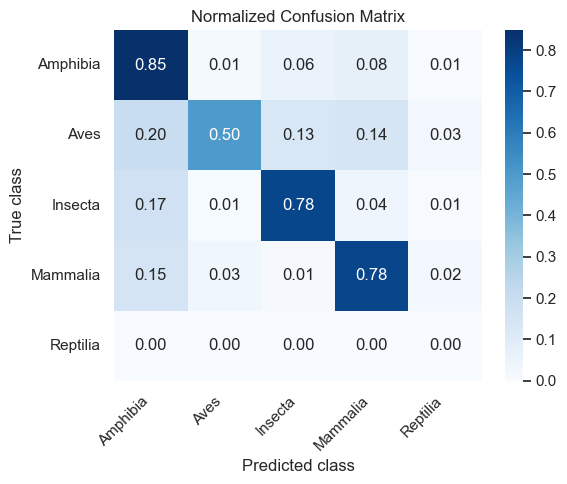

In [26]:
cm = confusion_matrix(
    val_true_class_name,
    val_pred_class_name,
    labels=le_class_name.classes_,
    normalize="true"
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=le_class_name.classes_,
    yticklabels=le_class_name.classes_,
    cbar=True
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

<Axes: >

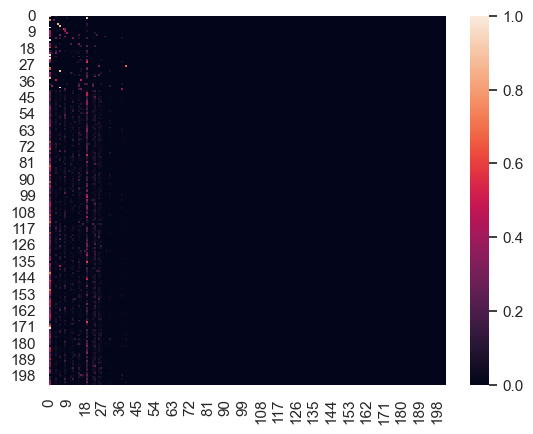

In [16]:
sns.heatmap(confusion_matrix(val_true_primary_label, val_pred_primary_label, normalize="true"))

## MIL